In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
# Load dataset
df = pd.read_csv("diabetes.csv")
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

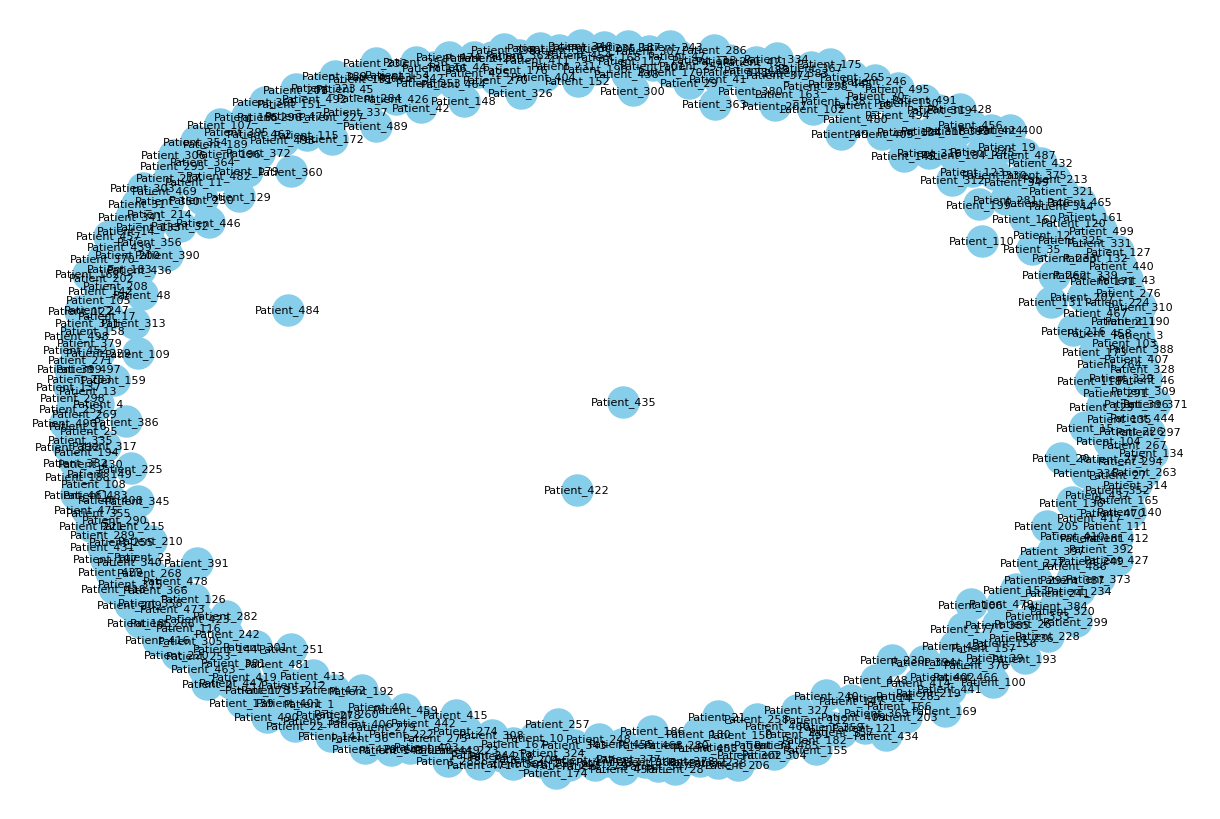

In [3]:
# Initialize a directed graph
G = nx.DiGraph()

# For simplicity, treat each patient as an entity (row index)
for idx, row in df.iterrows():
    patient_node = f"Patient_{idx}"
    G.add_node(patient_node, type='patient')
    
    # Add feature nodes and edges from patient to feature
    for col in df.columns:
        if col != 'Outcome':  # avoid redundancy for now
            feature_node = f"{col}_{row[col]}"
            G.add_node(feature_node, type='feature')
            G.add_edge(patient_node, feature_node, relation='has_feature_value')
    
    # Add outcome node and edge
    outcome_node = f"Outcome_{row['Outcome']}"
    G.add_node(outcome_node, type='outcome')
    G.add_edge(patient_node, outcome_node, relation='diagnosed_with')

# Visualize a subgraph of the first 5 patients for clarity
subgraph_nodes = [f"Patient_{i}" for i in range(5)]
subgraph = G.subgraph(subgraph_nodes + [n for n in G.nodes if any(p in n for p in subgraph_nodes)])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph, seed=42)
nx.draw(subgraph, pos, with_labels=True, node_size=500, node_color='skyblue', font_size=8)
plt.show()


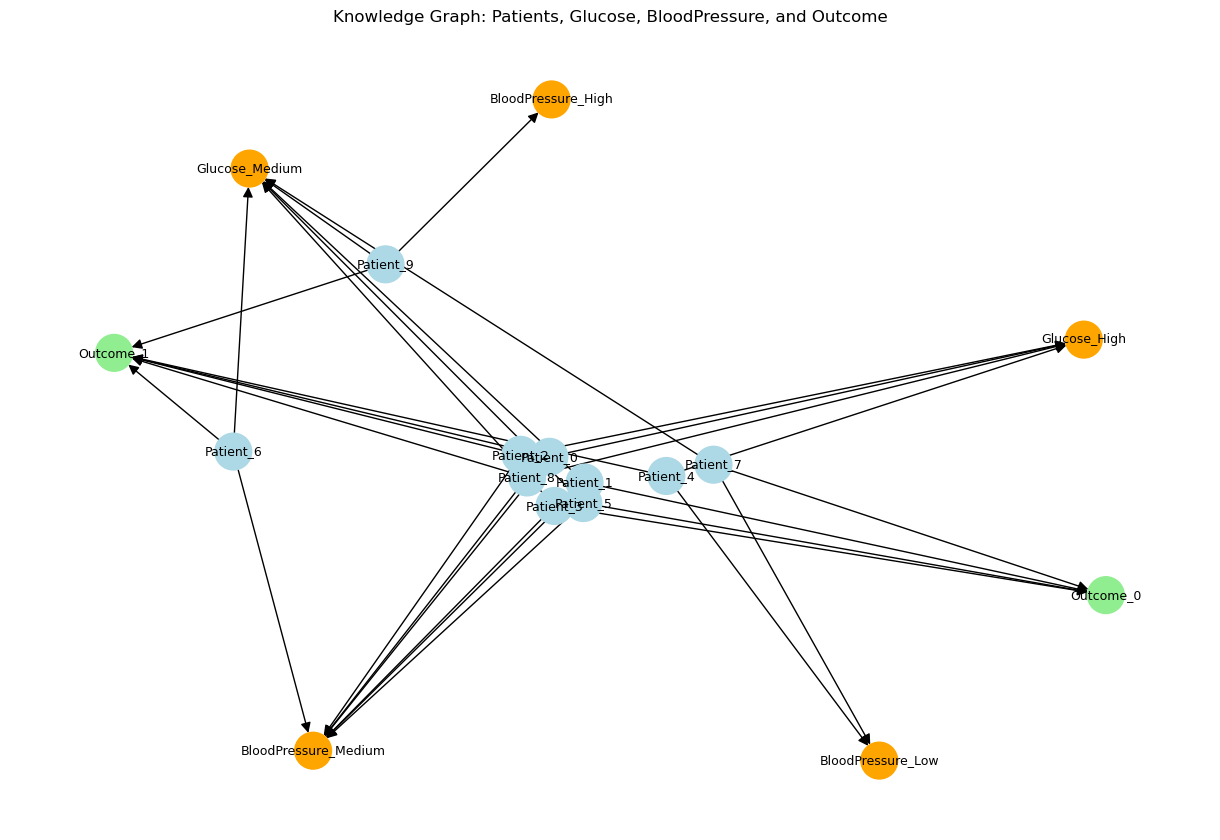

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("diabetes.csv")

# Discretize function for continuous features
def discretize_feature(series, bins=3, labels=None):
    if labels is None:
        labels = ['Low', 'Medium', 'High']
    return pd.cut(series, bins=bins, labels=labels, include_lowest=True)

# Discretize only Glucose and BloodPressure
df['Glucose_disc'] = discretize_feature(df['Glucose'])
df['BloodPressure_disc'] = discretize_feature(df['BloodPressure'])

# Initialize directed graph
G = nx.DiGraph()

# Build graph for first 10 patients for clarity
for idx, row in df.head(10).iterrows():
    patient_node = f"Patient_{idx}"
    G.add_node(patient_node, type='patient')
    
    # Feature nodes
    glucose_node = f"Glucose_{row['Glucose_disc']}"
    bp_node = f"BloodPressure_{row['BloodPressure_disc']}"
    
    G.add_node(glucose_node, type='feature')
    G.add_node(bp_node, type='feature')
    
    # Outcome node
    outcome_node = f"Outcome_{row['Outcome']}"
    G.add_node(outcome_node, type='outcome')
    
    # Edges
    G.add_edge(patient_node, glucose_node, relation='has_glucose_level')
    G.add_edge(patient_node, bp_node, relation='has_blood_pressure')
    G.add_edge(patient_node, outcome_node, relation='diagnosed_with')

# Visualize
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.5)

# Color nodes by type
color_map = []
for node in G.nodes(data=True):
    if node[1]['type'] == 'patient':
        color_map.append('lightblue')
    elif node[1]['type'] == 'feature':
        color_map.append('orange')
    else:
        color_map.append('lightgreen')

nx.draw(G, pos, with_labels=True, node_size=700, node_color=color_map, font_size=9, arrowsize=15)
plt.title("Knowledge Graph: Patients, Glucose, BloodPressure, and Outcome")
plt.show()


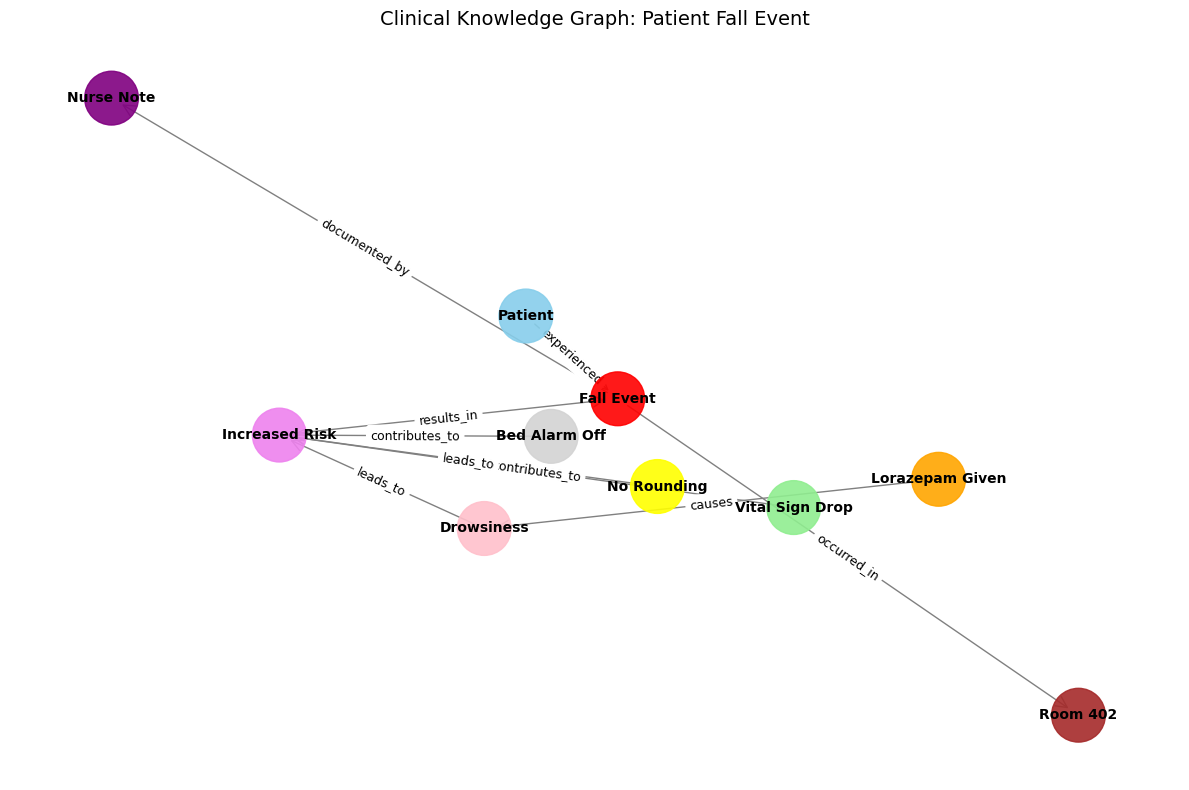

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize a directed graph
G = nx.DiGraph()

# --- Add nodes with types (for context) ---
nodes = [
    ("Patient", {"type": "Entity"}),
    ("Vital Sign Drop", {"type": "Event"}),
    ("Lorazepam Given", {"type": "Medication"}),
    ("Drowsiness", {"type": "Symptom"}),
    ("No Rounding", {"type": "Staff Activity"}),
    ("Bed Alarm Off", {"type": "Environment"}),
    ("Increased Risk", {"type": "Risk Factor"}),
    ("Fall Event", {"type": "Incident"}),
    ("Nurse Note", {"type": "Text Note"}),
    ("Room 402", {"type": "Location"}),
]

G.add_nodes_from(nodes)

# --- Add causal/timeline/contextual edges ---
edges = [
    ("Vital Sign Drop", "Increased Risk", {"relation": "contributes_to"}),
    ("Lorazepam Given", "Drowsiness", {"relation": "causes"}),
    ("Drowsiness", "Increased Risk", {"relation": "leads_to"}),
    ("No Rounding", "Increased Risk", {"relation": "leads_to"}),
    ("Bed Alarm Off", "Increased Risk", {"relation": "contributes_to"}),
    ("Increased Risk", "Fall Event", {"relation": "results_in"}),
    ("Fall Event", "Nurse Note", {"relation": "documented_by"}),
    ("Fall Event", "Room 402", {"relation": "occurred_in"}),
    ("Patient", "Fall Event", {"relation": "experienced"}),
]

G.add_edges_from([(src, dst, attrs) for src, dst, attrs in edges])

# --- Visualization ---
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# Node colors based on type
color_map = {
    "Entity": "skyblue",
    "Event": "lightgreen",
    "Medication": "orange",
    "Symptom": "pink",
    "Staff Activity": "yellow",
    "Environment": "lightgray",
    "Risk Factor": "violet",
    "Incident": "red",
    "Text Note": "purple",
    "Location": "brown",
}

node_colors = [color_map[G.nodes[n]["type"]] for n in G.nodes]

# Draw the graph
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500, alpha=0.9)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw edge labels
edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Clinical Knowledge Graph: Patient Fall Event", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
